In [1]:
# Permite recargar los módulos automáticamente si haces cambios en los .py
%load_ext autoreload
%autoreload 2

# Configuración para que los gráficos se vean aquí mismo
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os

# Añadimos la ruta del proyecto para poder importar tus módulos
sys.path.append(os.getcwd())

# Configuración de estilos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# Importamos TUS módulos (la lógica pesada está oculta aquí)
from inversion.data.make_dataset import load_data
from inversion.features.build_features import prepare_features, fit_and_save_scaler
from inversion.models.train_model import train_rf_model, evaluate_model
from inversion.utils import paths

# Definimos constantes
TICKER = "NVDA"
TARGET_COL = "close"
print(f" Iniciando Demo para {TICKER}")

🤖 Iniciando Demo para NVDA


In [3]:
# 1. Carga de Datos
# Nota: Asume que ya corriste main.py al menos una vez para generar el CSV,
# o puedes llamar a get_yfinance_history aquí si prefieres.
df = load_data(TICKER)

if df is not None:
    print(f" Datos cargados exitosamente: {df.shape[0]} registros.")
    display(df.tail()) # Muestra las últimas filas con estilo pandas
else:
    print(" Error: No se encontró el archivo. Ejecuta main.py primero para descargar los datos.")

 Datos cargados exitosamente: 4827 registros.


,open,high,low,close,volume,vwap,num_trades,return,volatility,rsi,ma_50,ma_200,hl_range,oc_range,log_volume,surprisePercent,target
timestamp,,,,,,,,,,,,,,,,,
2025-12-31,189.570007,190.559998,186.490005,186.500000,120100500,186.500000,0,-0.005545,0.019318,53.158385,186.350890,160.112394,4.069992,3.070007,18.603839,0.0,0
2026-01-02,189.839996,192.929993,188.259995,188.850006,148240500,188.850006,0,0.012601,0.019257,59.304528,186.504892,160.479599,4.669998,0.989990,18.814347,0.0,0
2026-01-05,191.759995,193.630005,186.149994,188.119995,183529700,188.119995,0,-0.003866,0.018802,67.522718,186.661892,160.832705,7.480011,3.639999,19.027887,0.0,0
2026-01-06,190.520004,192.169998,186.820007,187.240005,176862600,187.240005,0,-0.004678,0.018791,64.801306,186.763695,161.176363,5.349991,3.279999,18.990884,0.0,0
2026-01-07,188.570007,191.369995,186.559998,189.110001,153543200,189.110001,0,0.009987,0.018540,65.215064,186.820903,161.533520,4.809998,-0.539993,18.849493,0.0,0


In [4]:
# 2. Preparación de Features
# Tu función se encarga de calcular RSI, Volatilidad, Medias Móviles, etc.
X, y, feature_names = prepare_features(df, target_col=TARGET_COL)

print(f" Features generadas ({len(feature_names)}): {feature_names}")
display(X.head(3))

 Features generadas (9): ['return', 'log_volume', 'hl_range', 'oc_range', 'ma_5', 'ma_10', 'volatility', 'vwap', 'rsi']


,return,log_volume,hl_range,oc_range,ma_5,ma_10,volatility,vwap,rsi
timestamp,,,,,,,,,
2006-11-27,-0.045159,20.187625,0.062022,0.041065,0.555449,0.553783,0.030621,0.539557,59.450617
2006-11-28,0.018692,19.991307,0.045872,-0.021685,0.553340,0.553737,0.030771,0.549642,60.108139
2006-11-29,0.014734,20.178180,0.021370,-0.005479,0.554593,0.553951,0.027611,0.557741,60.236815


In [5]:
# 3. Split y Escalado
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Usamos tu función para escalar y guardar el scaler
print(" Escalando datos...")
scaler = fit_and_save_scaler(X_train, filename=f"scaler_demo_{TICKER}.pkl")
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenamiento
print(" Entrenando Random Forest...")
model = train_rf_model(X_train_scaled, y_train, filename=f"model_demo_{TICKER}.pkl")
print(" Modelo entrenado y guardado.")

 Escalando datos...
 Entrenando Random Forest...
      ...Configurando RandomForest (semilla=42)
 Modelo entrenado y guardado.


Resultados en Test Set:
-----------------------
 MSE (Error Cuadrático Medio): 0.00123
 R² Score: -0.1156


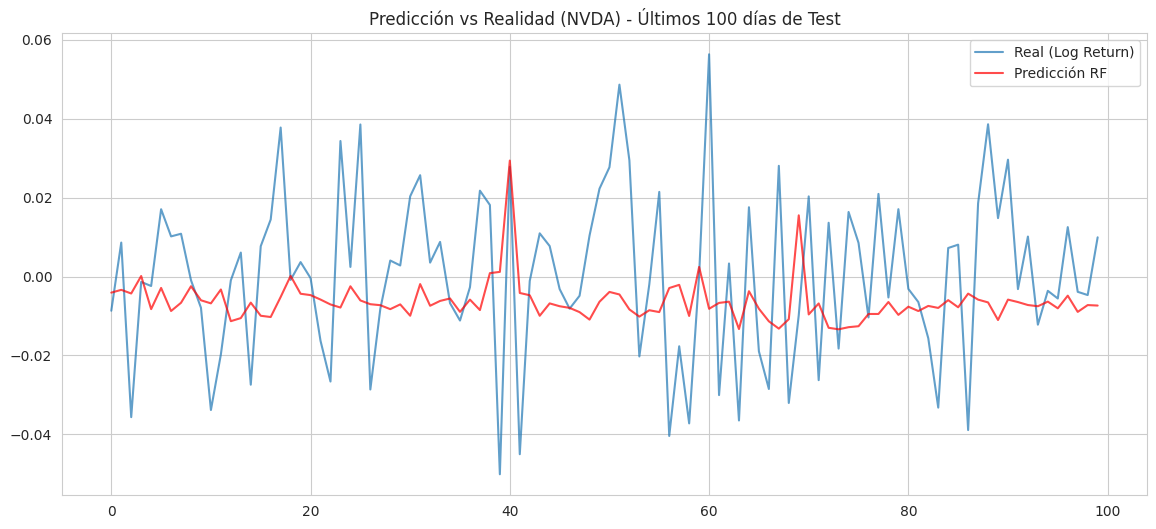

In [6]:
# 5. Evaluación
mse, r2 = evaluate_model(model, X_test_scaled, y_test)

print(f"Resultados en Test Set:")
print(f"-----------------------")
print(f" MSE (Error Cuadrático Medio): {mse:.5f}")
print(f" R² Score: {r2:.4f}")

# Visualización rápida de Predicción vs Realidad (últimos 100 días para claridad)
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-100:], label='Real (Log Return)', alpha=0.7)
plt.plot(y_pred[-100:], label='Predicción RF', alpha=0.7, color='red')
plt.title(f"Predicción vs Realidad ({TICKER}) - Últimos 100 días de Test")
plt.legend()
plt.show()

/tmp/ipykernel_5968/1535434574.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


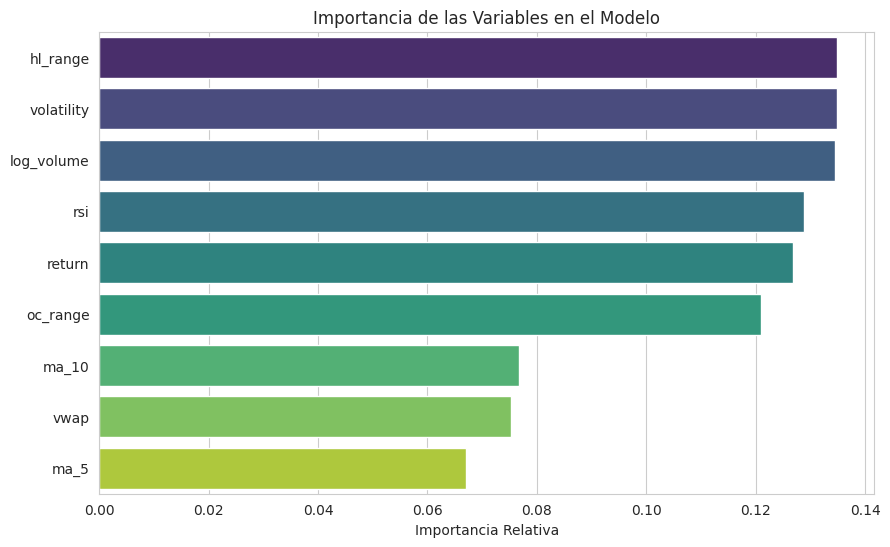

In [7]:
# 6. Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.title("Importancia de las Variables en el Modelo")
plt.xlabel("Importancia Relativa")
plt.show()

In [ ]:
# 7. Inferencia: ¿Qué pasará mañana?
# Tomamos la última fila de datos (HOY)
last_row = X.iloc[[-1]]
last_row_scaled = scaler.transform(last_row)

# Predicción del retorno logarítmico
pred_log_return = model.predict(last_row_scaled)[0]

# Convertir a precio
last_close_price = df.iloc[-1]['close']
predicted_price = last_close_price * np.exp(pred_log_return)
pct_change = (np.exp(pred_log_return) - 1) * 100
signal = "🟢 SUBE" if pred_log_return > 0 else "🔴 BAJA"

print(f" PREDICCIÓN PARA MAÑANA:")
print(f"==========================")
print(f"Precio Cierre Hoy:   ${last_close_price:.2f}")
print(f"Retorno esperado:    {pct_change:+.2f}%")
print(f"Precio Estimado:     ${predicted_price:.2f}")
print(f"Señal del Modelo:    {signal}")

 PREDICCIÓN PARA MAÑANA:
Precio Cierre Hoy:   $189.11
Retorno esperado:    -0.73%
Precio Estimado:     $187.73
Señal del Modelo:    🔴 VENTA/BAJA
